# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [1]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [2]:
# YOUR CODE HERE
base = "https://dlsun.github.io/pods/data/ml-1m/"
movies_url = base + 'movies.dat'
ratings_url = base + 'ratings.dat'
users_url = base + 'users.dat'
movies = pd.read_csv(movies_url, sep = '::', 
encoding_errors = 'ignore', 
header = None, 
names = ['movie_id', 'title', 'genre'])
ratings = pd.read_csv(ratings_url, sep = '::', 
encoding_errors = 'ignore', 
header = None,
names = ['user_id', 'movie_id', 'rating', 'timestamp' ])
users = pd.read_csv(users_url, sep = '::', 
encoding_errors = 'ignore', 
header = None,
names = ['user_id', 'gender', 'age', 'occupation', 'zip_code'])

<positron-console-cell-2>:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-2>:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-2>:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [3]:
movies.head()

,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [6]:
# YOUR CODE HERE
ratings_users = ratings.merge(users, on = 'user_id', how = 'left', validate="many_to_one")

age_labels = {1:"<18", 18:"18-24", 25:"25-34", 35:'35-44', 45:'45-49', 50:'50-55', 56:'56+'}
ratings_users['age_group'] = ratings_users['age'].map(age_labels)

(ratings_users.groupby('age_group')['rating'].agg(n_rating = "size", mean_rating = "mean")
.sort_values('mean_rating', ascending=False)
.reset_index())
#.agg allows us to aggregate by rows and columns



,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50-55,72490,3.714512
2,45-49,83633,3.638062
3,35-44,199003,3.618162
4,<18,27211,3.549520
5,25-34,395556,3.545235
6,18-24,183536,3.507573


The 56+ age group tends to give the highest ratings on average

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [7]:
summ_ratings = ratings.groupby('movie_id')['rating'].agg(n_rating = 'size', mean_ratings = 'mean').reset_index()
summ_ratings

,movie_id,n_rating,mean_ratings
0,1,2077,4.146846
1,2,701,3.201141
2,3,478,3.016736
3,4,170,2.729412
4,5,296,3.006757
...,...,...,...
3701,3948,862,3.635731
3702,3949,304,4.115132
3703,3950,54,3.666667
3704,3951,40,3.900000


In [8]:
# YOUR CODE HERE
ratings_movies = summ_ratings.merge(movies, on = 'movie_id', how = 'left')
ratings_movies
more_than_100 = ratings_movies[ratings_movies['n_rating'] >=100]
more_than_100.sort_values(by = 'mean_ratings',ascending = False)

,movie_id,n_rating,mean_ratings,title,genre
1839,2019,628,4.560510,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama
309,318,2227,4.554558,"Shawshank Redemption, The (1994)",Drama
802,858,2223,4.524966,"Godfather, The (1972)",Action|Crime|Drama
708,745,657,4.520548,"Close Shave, A (1995)",Animation|Comedy|Thriller
49,50,1783,4.517106,"Usual Suspects, The (1995)",Crime|Thriller
...,...,...,...,...,...
2190,2383,149,1.657718,Police Academy 6: City Under Siege (1989),Comedy
2612,2817,125,1.640000,Aces: Iron Eagle III (1992),Action|War
3556,3799,100,1.620000,Pokmon the Movie 2000 (2000),Animation|Children's
3353,3593,342,1.611111,Battlefield Earth (2000),Action|Sci-Fi


Among the movies with over 100 ratings, the movie with highest ratings is Seven Samurai (The Cirterion Collection), and the movie with the lowest ratings is Kazaam.

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [9]:
#YOUR CODE HERE
movie_rating = movies.merge(ratings, on = 'movie_id', how = 'left')
mean_rating = (movie_rating.groupby('movie_id')['rating'].agg(mean_rating='mean').reset_index())
mean_rating

,movie_id,mean_rating
0,1,4.146846
1,2,3.201141
2,3,3.016736
3,4,2.729412
4,5,3.006757
...,...,...
3878,3948,3.635731
3879,3949,4.115132
3880,3950,3.666667
3881,3951,3.900000


In [10]:

ratings_agegroup = users.merge(ratings, on = 'user_id', how = 'left')
ratings_agegroup['age_group'] = ratings_agegroup['age'].map(age_labels)
ratings_agegroup


,user_id,gender,age,occupation,zip_code,movie_id,rating,timestamp,age_group
0,1,F,1,10,48067,1193,5,978300760,<18
1,1,F,1,10,48067,661,3,978302109,<18
2,1,F,1,10,48067,914,3,978301968,<18
3,1,F,1,10,48067,3408,4,978300275,<18
4,1,F,1,10,48067,2355,5,978824291,<18
...,...,...,...,...,...,...,...,...,...
1000204,6040,M,25,6,11106,1091,1,956716541,25-34
1000205,6040,M,25,6,11106,1094,5,956704887,25-34
1000206,6040,M,25,6,11106,562,5,956704746,25-34
1000207,6040,M,25,6,11106,1096,4,956715648,25-34


In [11]:
movie_age = (ratings_agegroup.groupby('movie_id')['age_group'].agg(share_18_24=(lambda x: (x == '18-24').mean())).reset_index())
movie_age

,movie_id,share_18_24
0,1,0.215696
1,2,0.219686
2,3,0.223849
3,4,0.229412
4,5,0.219595
...,...,...
3701,3948,0.220418
3702,3949,0.269737
3703,3950,0.222222
3704,3951,0.075000


In [12]:
age_and_rating = mean_rating.merge(movie_age, on = 'movie_id', how = 'left')
age_and_rating

,movie_id,mean_rating,share_18_24
0,1,4.146846,0.215696
1,2,3.201141,0.219686
2,3,3.016736,0.223849
3,4,2.729412,0.229412
4,5,3.006757,0.219595
...,...,...,...
3878,3948,3.635731,0.220418
3879,3949,4.115132,0.269737
3880,3950,3.666667,0.222222
3881,3951,3.900000,0.075000


In [13]:
%pip install plotnine

C:\Users\mmori\miniconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 177 rows containing missing values.


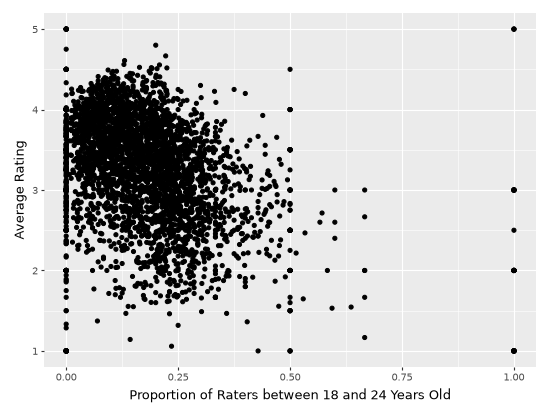

In [14]:
from plotnine import *
(ggplot(age_and_rating,
aes(
    x = 'share_18_24',
    y = 'mean_rating'
))
+ geom_point()
+ labs(x='Proportion of Raters between 18 and 24 Years Old', y = 'Average Rating')
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [15]:
# YOUR CODE HERE
ratings_by_movie = movies.merge(ratings, on = 'movie_id', how = 'outer')
rating_sum = (ratings_by_movie.groupby('movie_id')['rating'].agg(sum_ratings = 'sum').sort_values(by = 'sum_ratings', ascending=True).reset_index())
rating_sum
sum(rating_sum['sum_ratings'] == 0)

177

177 movies had zero ratings

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [16]:
# YOUR CODE HERE
one_star = ratings_by_movie[ratings_by_movie['rating'] == 1]
one_star
one_star_movies = (one_star.groupby('title')['rating'].agg(sum_one = 'sum').sort_values(by = 'sum_one').reset_index())
one_star_movies

,title,sum_one
0,"Actor's Revenge, An (Yukinojo Henge) (1963)",1.0
1,Across the Sea of Time (1995),1.0
2,"I Love You, Don't Touch Me! (1998)",1.0
3,Spirits of the Dead (Tre Passi nel Delirio) (1...,1.0
4,"Spiral Staircase, The (1946)",1.0
...,...,...
3269,Mission to Mars (2000),169.0
3270,Batman & Robin (1997),191.0
3271,"Blair Witch Project, The (1999)",219.0
3272,Battlefield Earth (2000),221.0


In [17]:
five_star = ratings_by_movie[ratings_by_movie['rating'] == 5]
five_star

five_star_movies = (five_star.groupby('title')['rating'].agg(sum_five = 'sum').sort_values(by = 'sum_five').reset_index())
five_star_movies['count_five'] = five_star_movies['sum_five'] / 5
five_star_movies


,title,sum_five,count_five
0,Monument Ave. (1998),5.0,1.0
1,"Month by the Lake, A (1995)",5.0,1.0
2,Mike's Murder (1984),5.0,1.0
3,Molly (1999),5.0,1.0
4,Modulations (1998),5.0,1.0
...,...,...,...
3227,Schindler's List (1993),7375.0,1475.0
3228,Star Wars: Episode V - The Empire Strikes Back...,7415.0,1483.0
3229,Raiders of the Lost Ark (1981),7500.0,1500.0
3230,Star Wars: Episode IV - A New Hope (1977),9130.0,1826.0


In [18]:
one_and_five = one_star_movies.merge(five_star_movies, on = 'title', how = 'inner')
one_and_five
#please refer to sum_one for the counts of how many one star ratings a movie received and count_five for the counts of how many 5 star ratings a movie received. 

,title,sum_one,sum_five,count_five
0,"Actor's Revenge, An (Yukinojo Henge) (1963)",1.0,5.0,1.0
1,Across the Sea of Time (1995),1.0,10.0,2.0
2,"I Love You, Don't Touch Me! (1998)",1.0,5.0,1.0
3,Spirits of the Dead (Tre Passi nel Delirio) (1...,1.0,5.0,1.0
4,"Spiral Staircase, The (1946)",1.0,65.0,13.0
...,...,...,...,...
2981,Mission to Mars (2000),169.0,160.0,32.0
2982,Batman & Robin (1997),191.0,85.0,17.0
2983,"Blair Witch Project, The (1999)",219.0,900.0,180.0
2984,Battlefield Earth (2000),221.0,15.0,3.0


2,958 movies received both a 1 star and 5 star rating. Please see the output above to see which movies they were and the counts of each rating type. The value 'sum_one' refers to the number of one star ratings received and the column 'count_five' refers to the number of five star ratings a movie received. 